# MNIST Example with Endurance

In [1]:
# You dont need this, this is for my convinience
import sys
import os
notebook_dir = os.path.dirname(os.getcwd())
sys.path.append(notebook_dir)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from nervos.utils import Module, Parameters
from nervos.dataloader import MNISTLoader
import glob

### Parameters


In [5]:
p = Parameters()
p.from_url('https://pastebin.com/raw/rdtizMB9')

In [8]:
allowed_levels = np.array(
           [1.0, 0.9679310906766183, 0.93760456888016, 0.9076014969897948, 0.8791824458963751,
            0.8496445762753205, 0.8209604023080539, 0.7935519996097391, 0.7671344494652823,
            0.741995145069934, 0.7168883624137776, 0.6916196780559918, 0.6682011978604938,
            0.644600313127789, 0.62183509569345, 0.5993915606793792, 0.5773725757606286,
            0.5557031995381914, 0.5343449008210679, 0.5132156682669483, 0.49230418996654846,
            0.47142452641101046, 0.4505597804358407, 0.4297537503397992, 0.4088284856499594,
            0.3877543957690631, 0.3664585982352714, 0.34477928874249386, 0.3228929359601,
            0.30055530869670194, 0.2778102406007755, 0.254499930537807, 0.2310277187732093,
            0.20723594557133454, 0.18259118371000224, 0.15743915341670922, 0.1322747507226366,
            0.10701030833083243, 0.08075324589934445, 0.05429645756955848, 0.027605300619291628,
            0.0]
        )

### Endurance Simulation Initialization

![](https://i.ibb.co/Ng8ChngX/download.png)

In [9]:
def find_closest_index(arr, target):
    arr = np.array(arr)
    return np.argmin(np.abs(arr - target))

def get_wt_ls_by_cyc(og_wt, max_interp, min_interp, cycle):
    max_val = max_interp[cycle]
    min_val = min_interp[cycle]
    # Normalize
    global_max = np.max(max_interp)
    global_min = np.min(min_interp)
    range_val = global_max - global_min
    
    if range_val == 0:
        return og_wt # Fallback

    ul = max_val / range_val
    ll = min_val / range_val
    
    ll_idx = find_closest_index(og_wt, ll)
    ul_idx = find_closest_index(og_wt, ul)
    
    if ll_idx == ul_idx:
        return np.full_like(og_wt, og_wt[ul_idx])

    step = 1 if ll_idx >= ul_idx else -1
    trend = og_wt[ul_idx : ll_idx + step : step]
    
    if len(trend) < 2:
        return og_wt # Fallback

    y0, y1 = trend[0], trend[-1]
    
    if y0 == y1:
        shape = np.zeros_like(trend)
    else:
        shape = (y0 - trend) / (y0 - y1)
        
    xi_orig = np.linspace(0, 1, len(shape))
    xi_new  = np.linspace(0, 1, len(og_wt)) # Interpolate to original length
    shape42 = np.interp(xi_new, xi_orig, shape)
    out = ul + (ll - ul) * shape42
    return out    

def generate_weight_lookup(lev_All):
    lc = 0.1/11
    x_vals = np.array([10, 100, 1000, 10000])
    log_x_vals = np.log10(x_vals)
    
    max_points = [0.3+5*lc, 0.2+10*lc,0.2+6*lc, -0.1+8*lc]
    min_points = [0+3*lc, 0+1*lc, 0+8*lc, -0.1+5*lc]

    x_all = np.arange(0, 10001)

    # Prepare empty arrays
    max_interp = np.zeros_like(x_all, dtype=float)
    min_interp = np.zeros_like(x_all, dtype=float)

    # Handle x = 0 separately
    max_interp[0] = max_points[0]
    min_interp[0] = min_points[0]

    # For x >= 1: interpolate in log10(x)
    x_nonzero = x_all[1:]
    log_x_nonzero = np.log10(x_nonzero)

    max_interp[1:] = np.interp(log_x_nonzero, log_x_vals, max_points)
    min_interp[1:] = np.interp(log_x_nonzero, log_x_vals, min_points)

    mmin = min(min(max_interp),min(min_interp))
    min_interp += -mmin
    max_interp += -mmin
    
    print("Generating cycle dependent weight lookup table...")
    weight_ls_Store = np.array([get_wt_ls_by_cyc(lev_All, max_interp, min_interp, i) for i in range(10001)])
    return weight_ls_Store

In [10]:
weight_lookup = generate_weight_lookup(allowed_levels)

Generating cycle dependent weight lookup table...


### Model


In [17]:

class MNIST_SNN(Module):
    def __init__(self, parameters, identifier=None):
        super().__init__(parameters, identifier)
        self.dataloader = MNISTLoader(parameters, classes=[i for i in range(5)])
        self.X_train, self.Y_train = self.dataloader.dataloader(
            preprocess=True, pca=False, size=parameters.training_images_amount
        )
        self.X_test, self.Y_test = self.dataloader.dataloader(
            preprocess=True, train=False, pca=False, size=parameters.testing_images_amount
        )
        self.get_spikeplots = False
        
        self.allowed_levels = allowed_levels

    def predict(self, un_processed_image, model_location):
        spike_train = np.array(self.dataloader.img2spiketrain(un_processed_image))
        synapses, neuron_label_map = self.load_model(model_location)
        return self.get_prediction(spike_train, synapses, neuron_label_map)


In [18]:
m = MNIST_SNN(p, "5classmnist_with_endurance")
m.initialise_layers([784, 60])
m.cycle_dependent_weight_lookup = weight_lookup
m.enable_cycle_dependent_weights = True

In [19]:
y = m.train()

Epoch 1/5
100/100 [========================================] [Max cycles for one synapse: 2655.0]
Testing...
Test set accuracy: 0.8
Time elapsed since training start: 284.202s
Epoch 2/5
100/100 [========================================] [Max cycles for one synapse: 3609.0]
Testing...
Test set accuracy: 0.95
Time elapsed since training start: 526.392s
Epoch 3/5
100/100 [========================================] [Max cycles for one synapse: 4884.0]
Testing...
Test set accuracy: 0.9
Time elapsed since training start: 774.322s
Epoch 4/5
100/100 [========================================] [Max cycles for one synapse: 5873.0]
Testing...
Test set accuracy: 0.9
Time elapsed since training start: 990.677s
Epoch 5/5
100/100 [========================================] [Max cycles for one synapse: 6516.0]
Testing...
Test set accuracy: 0.65
Time elapsed since training start: 1198.092s
Training complete!


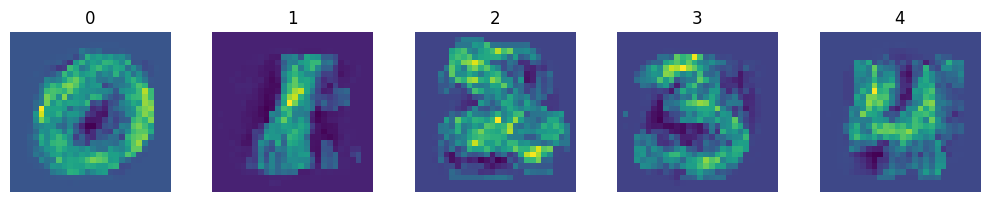

In [20]:
def visualise_synapse(synapses,labels):
    kk=28
    classes = {i:np.zeros((kk,kk)) for i in np.unique(labels)}
    for idx in range(len(synapses)):
        classes[labels[idx]]+= synapses[idx].reshape((kk,kk))
    
    i = 1
    plt.figure(figsize=(10,30))
    for k in classes.keys():
        plt.subplot(1,len(classes),i)
        plt.imshow(classes[k])
        plt.title(f"{k}")
        plt.tight_layout()
        plt.axis('off')
        i+=1
    plt.show()
    
visualise_synapse(m.learned_synapses[0],m.learned_neuron_label_map)

In [21]:
def accuracy(m2):
    spike_trains,labels = MNISTLoader(p,classes=[i for i in range(5)]).dataloader(train=False,preprocess=True,seed=123,size=1500)
    t = 0
    c = 0
    preds = []
    print('Calculating Accuracy')
    for st,label in zip(spike_trains,labels):
        pred = m2.get_prediction(st)
        preds.append(pred)
        if pred == label:
            c+=1
        t+=1
        
        print(f"\rTested {t} images",end='')
    print()
    print(c/t)
    return labels,preds,c/t

y_true,y_pred,_ = accuracy(m)

Calculating Accuracy
Tested 1500 images
0.5726666666666667


In [30]:
fp = glob.glob(os.path.join('storage', f'{m.identifier}*'))[0]
spike_trains,labels = MNISTLoader(p,classes=[i for i in range(5)]).dataloader(train=False,preprocess=True,seed=123,size=1500)
accs = []
for epoch in os.listdir(fp):
    m2 = MNIST_SNN(p)
    m2.initialise_layers([784,60])
    m2.cycle_dependent_weight_lookup = weight_lookup
    m2.enable_cycle_dependent_weights = True
    m2.load_model(os.path.join(fp, epoch, 'model.red'))
    accs.append(accuracy(m2)[-1])

Calculating Accuracy
Tested 1500 images
0.6546666666666666
Calculating Accuracy
Tested 1500 images
0.818
Calculating Accuracy
Tested 1500 images
0.768
Calculating Accuracy
Tested 1500 images
0.702
Calculating Accuracy
Tested 1500 images
0.5726666666666667


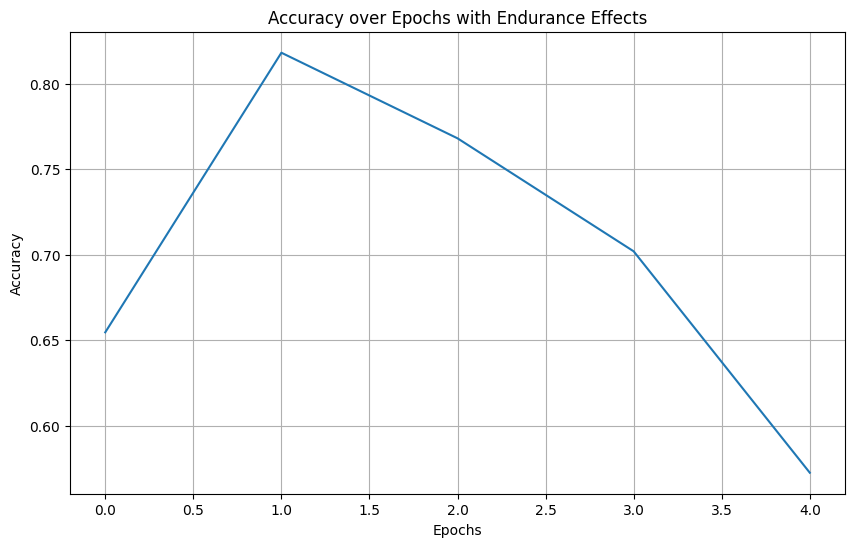

In [35]:
plt.figure(figsize=(10,6))
plt.plot(accs)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs with Endurance Effects')
plt.grid('on',which='both')
plt.show()